In [1]:
import json
from models.gru import GRU
from models.tcgn import STGNN
from models.tsfm_tuning.tsfm_finetuning import TimesFMFineTuning
import torch
import matplotlib.pyplot as plt

/home/ricca/miniconda3/envs/traffic_data_pd/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import matplotlib.pyplot as plt

plt.rcParams["font.size"] = 14

# Specific adjustments
plt.rcParams["axes.titlesize"] = 18    # Title font size
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 14    # X/Y label size
plt.rcParams["xtick.labelsize"] = 12   # X tick labels
plt.rcParams["ytick.labelsize"] = 12   # Y tick labels
plt.rcParams["legend.fontsize"] = 12   # Legend labels

In [3]:
def load_model_from_file(
    hyper_params_path: str, 
    ckp_path: str,
    horizon=30, 
    F_static=21, 
    use_static=True, 
    use_time=True,
    device="cuda",
    model_type = "gru",
    fusion_type = "concat",
    dec_type="mlp",
    dyn_adj=True
):
    with open(hyper_params_path, 'r') as f:
        hyper_params = json.load(f)

    if model_type == "gru":
        model = GRU(
            conf=hyper_params,
            in_channels=1,
            out_channels=1,
            horizon=horizon,
            F_static=F_static,
            use_static=use_static,
            use_time=use_time,
            fusion_type=fusion_type,
            dec_type=dec_type
        )
    elif model_type == "tsfm":
        model = TimesFMFineTuning(
            conf = hyper_params,
            out_channels=1,
            horizon = horizon,
            F_static=F_static,
            use_static=use_static,
            use_time=use_time
        )
    elif model_type == "stgnn":
        model = STGNN(
            conf = hyper_params,
            in_channels = 1,
            out_channels = 1,
            horizon = horizon,
            F_static = F_static,
            use_static=use_static,
            use_time = use_time,
            fusion_type=fusion_type,
            dec_type=dec_type,
            dyn_adj=dyn_adj
        )
    else:
        raise ValueError("Not supported model")
    
    ckpt = torch.load(ckp_path, map_location=device)
    model.load_state_dict(ckpt["model_state_dict"])
    
    model = model.to(device)
    return model


import yaml

def load_config(config_path='./conf/edenn.yml'):
    """
    Returns a dictionary of the specified config file
    """
    with open(config_path, 'r') as file:
        config = yaml.safe_load(file)
    return config


In [4]:
import math
from copy import deepcopy

def get_non_overlapping_windows(time_windows, history=30, stride=4):
    total_seq_len = history
    
    # Number of dataset items that cover each full sequence
    jump = math.ceil(total_seq_len / stride)

    non_overlap = []
    
    for i in range(0, len(time_windows), jump):
        non_overlap.append(time_windows[i])
    
    return non_overlap


def get_preds(model: torch.nn.Module, time_windows:list, scaler = None, horizon_steps = 5, scaler_edges = None):
    model = model.eval()
    all_preds = []
    all_true = []
    time_windw_copy = deepcopy(time_windows)
    
    with torch.no_grad():
        for i, tw in enumerate(time_windw_copy):
            
            if scaler is not None:
                tw.x = scaler.transform(tw.x).detach()
            
            if scaler_edges is not None:
                tw.edge_attr = [scaler_edges.transform(edge_attr) for edge_attr in tw.edge_attr]
            
            predictions = model(tw)   # Shape (N, horizon_len, 1)
            y_true = tw.y # Shape (N, horizon_len, 1)
            
            if scaler is not None:
                predictions = scaler.inverse_transform(predictions).detach()
                # tw.x = scaler.inverse_transform(tw.x).detach()
            
            all_preds.append(predictions)
            all_true.append(y_true)
            
            if i > horizon_steps:
                break
               
    return torch.cat(all_preds, dim=1), torch.cat(all_true, dim=1)
    
    

def plot_results(predictions_dict, y_true, node_idx=0, history_len = 30, horizon_len=30):
            
    true = y_true[node_idx].squeeze(-1).cpu()
    horizon = len(true)

    plt.figure(figsize=(10, 6))
    
    # Plot ground truth
    plt.plot(range(horizon), true, label="Valore reale", linewidth=1)

    # Plot predictions for each model
    for model_name, preds in predictions_dict.items():
        pred = preds[node_idx].squeeze(-1).cpu()
        plt.plot(range(horizon), pred, "--", linewidth=2, label=model_name)

    window_starts = range(history_len, horizon, horizon_len)
    for t in window_starts:
        plt.axvline(x=t, linestyle=":", color="red", alpha=1.0)
    
    plt.title(f"Predizione vs. Curva reale (incrocio {node_idx})")
    plt.xlabel("Tempo")
    plt.ylabel("Numero veicoli")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

## GRU Plots

### Load data

In [5]:
from experiments.experiments_gru import ExperimentGRU

In [6]:
conf = load_config("./conf/gru.yml")

In [8]:
exp = ExperimentGRU(
    config = conf,
    n_trials=20,
    data_name="traffic_pd_prod_hi30_ho30_st4_loops_2",
    data_source="pd",
    history=30,
    horizon=30,
    stride=4,
    flow_adj=False,
    traffic_cam_data=True,
    loops_data=True
)

scaler, _ = exp.pre_processing()
non_overlap_test_data = get_non_overlapping_windows(exp.test_data, history=30)


In [9]:
gru_model = load_model_from_file(
    hyper_params_path = "./trained_models/GRU/data_with_loops_seed_0_CONCAT/0/best_params.json",
    ckp_path="./trained_models/GRU/data_with_loops_seed_0_CONCAT/0/ckpt.pth",
    horizon=30,
    device=exp.device,
    F_static=37,
    fusion_type="concat"
)

y_pred_gru, y_true = get_preds(
    model=gru_model,
    time_windows=non_overlap_test_data[50:],
    scaler=scaler,
    horizon_steps=10
)


In [10]:
gru_model_auto = load_model_from_file(
    hyper_params_path = "./trained_models/GRU/data_with_loops_seed_0_CONCAT_auto/0/best_params.json",
    ckp_path="./trained_models/GRU/data_with_loops_seed_0_CONCAT_auto/0/ckpt.pth",
    horizon=30,
    device=exp.device,
    F_static=37,
    fusion_type="concat",
    dec_type="gru"
)

y_pred_gru_auto, y_true_auti = get_preds(
    model=gru_model_auto,
    time_windows=non_overlap_test_data[50:],
    scaler=scaler,
    horizon_steps=10
)

## STGNN plots

Graph:  G₀───────────G₁───────────G₂───────────
Time:   |----|----|----|----|----|----|----|----|
Data:    x₀   x₁   x₂   x₃   x₄   x₅   x₆   x₇
                        ↑    ↑    ↑
                        mapped to G₀


In [5]:
from experiments.experiment_stgnn import ExperimentSTGNN

conf = load_config("./conf/stgnn.yml")

In [6]:
exp_stgnn = ExperimentSTGNN(
    config = conf,
    n_trials=20,
    data_name="traffic_pd_prod_hi30_ho30_st4_loops_dyn_avgtt",
    data_source="pd",
    history=30,
    horizon=30,
    stride=4,
    flow_adj=True,
    traffic_cam_data=True,
    loops_data=True,
    dyn_adj=True
)

scaler_ts, scaler_edges = exp_stgnn.pre_processing()
non_overlap_test_data = get_non_overlapping_windows(exp_stgnn.test_data, history=30)

stgnn_model = load_model_from_file(
    hyper_params_path = "./trained_models/STGNN/data_with_loops_seed_0_avg_tt_dyn/0/best_params.json",
    ckp_path="./trained_models/STGNN/data_with_loops_seed_0_avg_tt_dyn/0/ckpt.pth",
    horizon=30,
    device=exp_stgnn.device,
    F_static=37,
    fusion_type="concat",
    model_type="stgnn",
    dec_type="mlp",
    dyn_adj=True
)

In [13]:
y_pred_stgnn, y_true_stgnn = get_preds(
    model=stgnn_model,
    time_windows=non_overlap_test_data[50:],
    scaler=scaler_ts,
    horizon_steps=10,
    scaler_edges=scaler_edges
)

## TSFM Plots

In [10]:
from experiments.experiments_tuning_tsfm import ExperimentTSFM

conf = load_config("./conf/tsfm.yml")

In [11]:
exp = ExperimentTSFM(
    config = conf,
    n_trials=20,
    data_name="traffic_pd_prod_hi30_ho30_st4",
    data_source="pd",
    history=30,
    horizon=30,
    stride=4
)

scaler = None
non_overlap_test_data = get_non_overlapping_windows(exp.test_data, history=30)

Downloaded.


In [12]:
tsfm_model = load_model_from_file(
    hyper_params_path = "./trained_models/TSFM/data_fusion_tsfm_seed_0/0/best_params.json",
    ckp_path="./trained_models/TSFM/data_fusion_tsfm_seed_0/0/ckpt.pth",
    horizon=30,
    device=exp.device,
    model_type="tsfm"
)

y_pred_tsfm, y_true_tsfm = get_preds(
    model=tsfm_model,
    time_windows=non_overlap_test_data,
    scaler=scaler,
    horizon_steps=10
)

In [13]:
preds = {
    "GRU": y_pred_gru,
    "TSFM": y_pred_tsfm
}

## Plots

In [14]:
preds = {
    "GRU": y_pred_gru,
    "GRU-Autoreg": y_pred_gru_auto,
    "STGNN": y_pred_stgnn
}

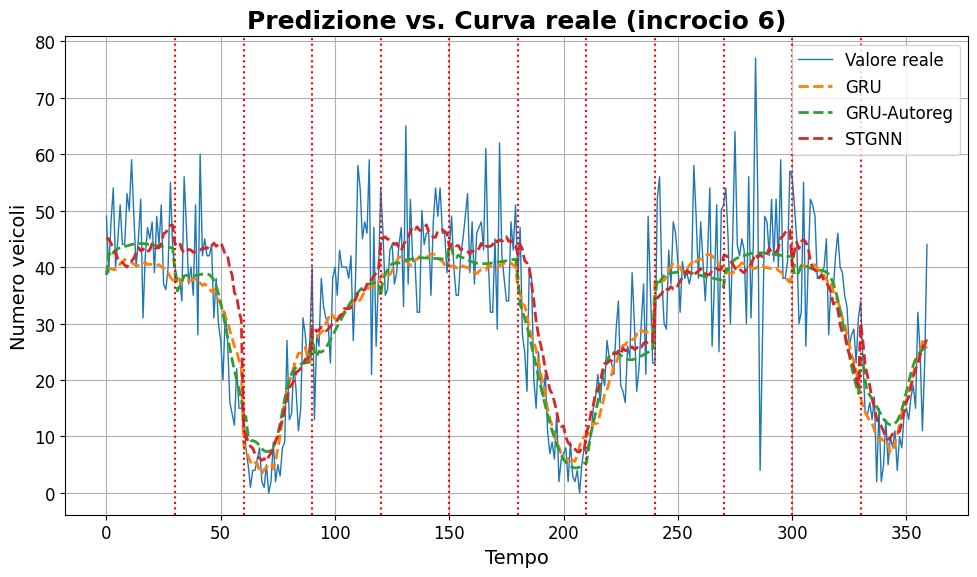

In [15]:
plot_results(preds, y_true_stgnn, node_idx=6)

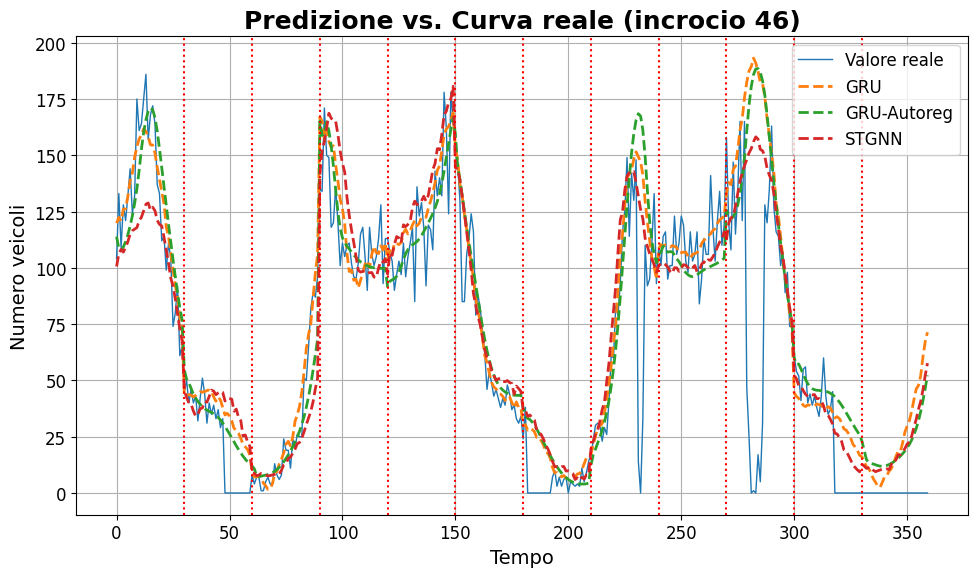

In [16]:
plot_results(preds, y_true_stgnn, node_idx=46)

## Results plots

In [ ]:
from old_exp.train_and_eval import mae_metric, rmse_metric
import numpy as np
from copy import deepcopy


def interp_points(signal, degree=3, device="cuda"):
    N,T, _ = signal.shape
    signal = signal.detach().cpu().numpy()
    signal_smoothed = np.zeros_like(signal)
    x = np.arange(T)
    for node_idx in range(N):
        y = signal[node_idx, :, 0]
        coeffs = np.polyfit(x, y, degree)
        y_smooth = np.polyval(coeffs, x)
        signal_smoothed[node_idx, :, 0] = y_smooth
    
    return torch.from_numpy(signal_smoothed).to(device)


def eval_by_sensor(model, test_data, sensors_to_exclude, scaler=None, smooth_true = False, smooth_pred=False, device="cuda", scaler_edges = None):
    total_mae = []
    total_rmse = []
    test_data_copy = deepcopy(test_data)
    for d in test_data_copy:
        mask = d.mask_out
        if len(sensors_to_exclude)> 0:
            mask[sensors_to_exclude, : , :] = 0
        
        d.mask_out = mask
        if scaler is not None:
            d.x = scaler.transform(d.x)
        
        if scaler_edges is not None:
            d.edge_attr = [scaler_edges.transform(edge_attr) for edge_attr in d.edge_attr]
            
        y_pred = model(d) if not smooth_pred else interp_points(d.y)
        y_true = d.y if not smooth_true else interp_points(d.y, device=device)
        
        if scaler:
            y_pred = scaler.inverse_transform(y_pred)
            
        y_pred = y_pred[d.mask_out == 1]
        y_true = y_true[d.mask_out == 1]
        
        if len(y_pred) == 0:
            continue
        
        mae = mae_metric(y_pred, y_true).item()
        rmse = rmse_metric(y_pred, y_true).item()
        
        total_mae.append(mae)
        total_rmse.append(rmse)
    
    return float(np.mean(total_mae)), float(np.mean(total_rmse))


def test_error_by_sensor_type(model, test_data, sensor_type="TrafficCam", scaler=None, scaler_edges = None):   
    if sensor_type == "TrafficCam":
        sensors_to_exclude = [44, 45, 46, 47]
    elif sensor_type == "Spire":
        sensors_to_exclude = list(range(45))
    elif sensor_type == "All":
        sensors_to_exclude = []
    else:
        raise ValueError("Sensor type not recognized")
    
    test_mae, test_rmse = eval_by_sensor(model, test_data, sensors_to_exclude, scaler, smooth_true=False, device="cuda", scaler_edges=scaler_edges)
    
    print(f"Test MAE for {sensor_type}: {test_mae}") 
    print(f"Test RMSE for {sensor_type}: {test_rmse}")
        
    
def test_error_smoothing(model, test_data, scaler = None, smooth_true=True, smooth_pred=False, scaler_edges = None):
    test_mae, test_rmse = eval_by_sensor(model, test_data, [], scaler, smooth_true=smooth_true, smooth_pred=smooth_pred, scaler_edges=scaler_edges)
    
    print(f"Test MAE on smoothed data: {test_mae}") 
    print(f"Test RMSE on smoothed data: {test_rmse}")
    

In [18]:
test_error_by_sensor_type(
    model = gru_model,
    test_data=exp.test_data,
    sensor_type="All",
    scaler = scaler
)

print()

test_error_by_sensor_type(
    model = gru_model,
    test_data=exp.test_data,
    sensor_type="TrafficCam",
    scaler = scaler
)

print()

test_error_by_sensor_type(
    model = gru_model,
    test_data=exp.test_data,
    sensor_type="Spire",
    scaler = scaler
)

Test MAE for All: 5.914705521410162
Test RMSE for All: 10.84414175640453

Test MAE for TrafficCam: 5.540488734678789
Test RMSE for TrafficCam: 9.712348761125044

Test MAE for Spire: 29.49422455505586
Test RMSE for Spire: 41.41620451743614


In [19]:
test_error_by_sensor_type(
    model = gru_model_auto,
    test_data=exp.test_data,
    sensor_type="All",
    scaler = scaler
)

print()

test_error_by_sensor_type(
    model = gru_model_auto,
    test_data=exp.test_data,
    sensor_type="TrafficCam",
    scaler = scaler
)

print()

test_error_by_sensor_type(
    model = gru_model_auto,
    test_data=exp.test_data,
    sensor_type="Spire",
    scaler = scaler
)

Test MAE for All: 5.777958887273615
Test RMSE for All: 10.844446674693714

Test MAE for TrafficCam: 5.3586238900097936
Test RMSE for TrafficCam: 9.592310359694741

Test MAE for Spire: 30.298894189333133
Test RMSE for Spire: 41.9983389254467


In [8]:
test_error_by_sensor_type(
    model = stgnn_model,
    test_data=exp_stgnn.test_data,
    sensor_type="All",
    scaler = scaler_ts,
    scaler_edges=scaler_edges
)

print()

test_error_by_sensor_type(
    model = stgnn_model,
    test_data=exp_stgnn.test_data,
    sensor_type="TrafficCam",
    scaler = scaler_ts,
    scaler_edges=scaler_edges
)

print()

test_error_by_sensor_type(
    model = stgnn_model,
    test_data=exp_stgnn.test_data,
    sensor_type="Spire",
    scaler = scaler_ts,
    scaler_edges=scaler_edges
)

Test MAE for All: 5.820161144950173
Test RMSE for All: 10.539740315350619

Test MAE for TrafficCam: 5.452950675704263
Test RMSE for TrafficCam: 9.397138587778265

Test MAE for Spire: 28.715623665863358
Test RMSE for Spire: 39.91235774671528


In [22]:
test_error_smoothing(gru_model, exp.test_data, scaler)

Test MAE on smoothed data: 4.087830227938565
Test RMSE on smoothed data: 8.290048711083152


In [23]:
test_error_smoothing(gru_model_auto, exp.test_data, scaler)

Test MAE on smoothed data: 3.8800933413072065
Test RMSE on smoothed data: 8.14882321357727


In [28]:
test_error_smoothing(None, exp.test_data, None, smooth_true=False, smooth_pred=True)

Test MAE on smoothed data: 4.17568665005944
Test RMSE on smoothed data: 6.4643970628218215


In [ ]:
# import numpy as np

# test_results = {
#     "GRU": [6.1998, 6.2019, 6.1971],
#     "GRU-with-context": [4.6352, 4.6805, 4.7000],
#     "TSFM-zero-shot": [7.9798, 7.9798, 7.9798],
#     "TSFM-tuning": [10.7583, 10.8001, 10.7635],
#     "TSFM-tuning-with-context": [5.3002, 5.4635, 5.3915],
#     "LB-Baseline": [8.3549, 8.3549, 8.3549]
# }

# MODEL_COLOR_MAP = {
#     "GRU":                  "#1f77b4",  
#     "GRU-with-context":     "#4c9fdb",  
#     "TSFM-zero-shot":                       "#2ca02c",  
#     "TSFM-tuning":                "#1a651a",  
#     "TSFM-tuning-with-context":   "#62b962",
#     "LB-Baseline":          "#7f7f7f"
# }

# models = list(test_results.keys())
# means = [np.mean(vals) for vals in test_results.values()]
# stds = [np.std(vals) for vals in test_results.values()]

# colors = [MODEL_COLOR_MAP[m] for m in models]

# plt.figure(figsize=(10, 6))
# plt.bar(models, means, yerr=stds, capsize=5, color=colors)
# plt.ylabel("MAE")
# plt.xticks(rotation=45, ha="right")
# plt.title("Test MAE with Standard Deviation")
# plt.tight_layout()
# plt.show()

In [ ]:
# import numpy as np

# test_results = {
#     "GRU": [6.1998, 6.2019, 6.1971],
#     "GRU-with-POI": [4.6352, 4.6805, 4.7000],
#     "GRU-all-context": [4.7043, 4.6515, 4.7097]
# }

# MODEL_COLOR_MAP = {
#     "GRU":                  "#1f77b4",  
#     "GRU-with-POI":     "#4c9fdb",  
#     "GRU-all-context": "#d38eee"
# }

# models = list(test_results.keys())
# means = [np.mean(vals) for vals in test_results.values()]
# stds = [np.std(vals) for vals in test_results.values()]

# colors = [MODEL_COLOR_MAP[m] for m in models]

# plt.figure(figsize=(10, 6))
# plt.bar(models, means, yerr=stds, capsize=5, color=colors)
# plt.ylabel("MAE")
# plt.xticks(rotation=45, ha="right")
# plt.title("Test MAE with Standard Deviation")
# plt.tight_layout()
# plt.show()